# Perovskite/Si Tandem Energy Yield with Degradation
Predicts real-world operational lifetime (T80, T90,Agg) and hourly energy yield of a
Perovskite/Si tandem using the combined Arrhenius + power-law degradation model of
Orooji et al. (2026), parameterised from the accelerated aging data of Zhao et al. (2022).

Models covered:
1. Device-level CE degradation factor - perovskite_degradation_factor() (D046, CsPbI3)
2. Tandem energy yield with PVCircuit Multi2T - hourly tandem Pmp, aggregated power ratio
   PR_Agg(t), and T90,Agg.
3. Multi-location comparison - assess multiple locations with T80 and T90 thresholds.

Key equations:

k(T_i, I_i) = k_0 * exp(-E_a / (k_B T_i)) * (I_i / I_ref)^gamma

DF(i) = A1 * exp(-k_fast * 1h) + A2 * exp(-k_slow * 1h) + B
DF_total(t) = product_{i=1..t} DF(i)

PR_Agg(t) = [sum_{i=1..t} P_deg(i)] / [sum_{i=1..t} P_ref(i)]

References:
- Orooji et al. (2026) EES Solar. doi: 10.1039/d6el00021e
- Zhao et al. (2022) Science 377, 307-310. doi: 10.1126/science.abn5679

## Executive summary (what matches, what does not)

This notebook reproduces the Orooji et al. tandem degradation workflow with pvdeg + PVCircuit and compares it against the published outcomes.

Key outcomes:
- WA (temperate) is reproduced closely for $T_{90,Agg}$ (about 42 months).
- AZ (hot/arid) degrades substantially faster in pvdeg than published (about 16.7 vs 26 months).
- 12-month CE values for AZ/WA are close to Orooji Fig. 4 values.
- Weather severity is not the cause of the AZ gap in this workflow: pvdeg's reconstructed $T_{cell}$ and POA for AZ are not harsher than the digitized paper curves.

Takeaway:
- The major unresolved issue is the AZ long-horizon $T_{90,Agg}$ gap, not a broad failure across all sites.

## 1. Imports and data

In [ ]:
import os
import tempfile
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go
import pvcircuit as pvc

# Tutorial assumption: run from repo root or tutorials/04_scenario
_cwd = os.getcwd()
if os.path.isdir(os.path.join(_cwd, "tutorials", "data")):
    REPO_ROOT = _cwd
else:
    REPO_ROOT = os.path.abspath(os.path.join(_cwd, "..", ".."))

TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Lifetime threshold e.g. 0.90 for T90
T_THRESHOLD = 0.90
T_LABEL = f"T{int(T_THRESHOLD * 100)}"  # e.g. "T90" or "T80"

# A single TMY year rarely crosses T_THRESHOLD, so weather is tiled to N_YEARS
# everywhere in this notebook (Section 3 onward).
N_YEARS = 4  # covers Orooji's published T90 range (26-42 months) for all locations

# Tandem EY assumptions in this notebook:
# - PVCircuit Multi2T electrical model for the Perovskite/Si tandem
# - CE degradation from D046 is applied to top-cell photocurrent only
# - bottom-cell photocurrent is not directly degraded by CE

# Top/bottom cell parameters
Eg_top, Eg_bot = 1.68, 1.12  # eV
J01_top, J01_bot = 2.6e-18, 5.7e-15  # A/cm^2  (n=1 diode, 25 C)
n_top, n_bot = 1.3, 1.0
Rser_top, Rser_bot = 1.4, 1.0  # ohm*cm^2
Rsh_top, Rsh_bot = 1300, 2800  # ohm*cm^2

In [ ]:


# Convert absolute J0 -> J0ratio at reference Eg
def j0_to_j0ratio(J01, n, Eg, TC=25):
    j = pvc.Junction(Eg=Eg, n=[n], TC=TC)
    j._J0init([J01])
    return float(j.J0ratio[0])


def load_measured_eqe(csv_path, wvl_grid):
    """Load measured top/bottom EQE from CSV and interpolate onto wvl_grid.

    Expected CSV columns: wavelength_nm, eqe_top, eqe_bot (fractional EQE, 0-1).
    Returns (eqe_top, eqe_bot) arrays sampled at wvl_grid.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Measured EQE file not found: {csv_path}\n"
            "This tutorial requires digitized top/bottom EQE data "
            "(columns: wavelength_nm, eqe_top, eqe_bot) from Liu et al. 2024 "
            "Nature 635, 596-603 (the reference device Orooji et al. parameterize)."
        )
    data = pd.read_csv(csv_path)
    eqe_top = np.interp(
        wvl_grid, data["wavelength_nm"], data["eqe_top"], left=0.0, right=0.0
    )
    eqe_bot = np.interp(
        wvl_grid, data["wavelength_nm"], data["eqe_bot"], left=0.0, right=0.0
    )
    return eqe_top, eqe_bot


def reference_jsc_from_spectrum(eqe_top, eqe_bot, spectrum="global"):
    """Integrate measured top/bottom EQE (sampled on pvc.qe.wvl) against an
    AM1.5 spectrum to get reference Jsc [mA/cm^2] for each subcell."""
    wvl = pvc.qe.wvl
    eqe_2j = np.column_stack([eqe_top, eqe_bot])
    jsc = np.asarray(pvc.qe.JintMD(eqe_2j, wvl, spectrum, wvl), dtype=float).reshape(-1)
    return float(jsc[0]), float(jsc[1])


jr_top = j0_to_j0ratio(J01_top, n_top, Eg_top)
jr_bot = j0_to_j0ratio(J01_bot, n_bot, Eg_bot)

# Build Multi2T tandem
tandem = pvc.Multi2T(name="pk168_si", Eg_list=[Eg_top, Eg_bot])
tandem.j[0].set(Eg=Eg_top, n=[n_top], J0ratio=[jr_top], Gsh=1 / Rsh_top)
tandem.j[1].set(Eg=Eg_bot, n=[n_bot], J0ratio=[jr_bot], Gsh=1 / Rsh_bot)
tandem.set(Rs2T=Rser_top + Rser_bot)

# Reference subcell currents from AM1.5G, using measured EQE from
# tutorials/data/orooji_liu_eqe.csv (columns: wavelength_nm, eqe_top,
# eqe_bot), digitized from the Liu et al. 2024 Nature 635, 596-603
# reference device that Orooji et al. parameterize against.
EQE_CSV_PATH = os.path.join(TUTORIALS_DATA, "orooji_liu_eqe.csv")
_eqe_top_arr, _eqe_bot_arr = load_measured_eqe(EQE_CSV_PATH, pvc.qe.wvl)
print(f"Using measured EQE from {EQE_CSV_PATH}")

JSC_TOP_REF, JSC_BOT_REF = reference_jsc_from_spectrum(
    _eqe_top_arr, _eqe_bot_arr, spectrum="global"
)

# Set reference Jext on the tandem template (A/cm^2)
tandem.j[0].set(Jext=JSC_TOP_REF / 1000.0)
tandem.j[1].set(Jext=JSC_BOT_REF / 1000.0)

mpp_ref = tandem.MPP()
print(tandem)
print(
    f"Reference subcell Jsc from spectrum: top={JSC_TOP_REF:.2f}, bottom={JSC_BOT_REF:.2f} mA/cm^2"
)
print(f"Device Isc from tandem.MPP(): {mpp_ref['Isc']*1000:.2f} mA/cm^2")
print("Note: MPP() returns device-level Isc, not per-subcell currents.")

Using measured EQE from C:\Users\rdaxini\Documents\GitHub\PVDegradationTools_NREL\tutorials\data\orooji_liu_eqe.csv
pk168_si: <pvcircuit.multi2T.Multi2T class>
T = 25.0 C, Rs2T= 2.4 Ohm*cm^2

j[0]: <pvcircuit.junction.Junction class>
Eg = 1.68 eV, TC = 25.0 C
Jext = 20.7 mA/cm^2, JLC = 0.0 mA/cm^2
Gsh = 0.000769231 S/cm^2, Rser = 0 Ohm*cm^2
lightA = 1 cm^2, totalA = 1 cm^2
pn = -1, beta = 0, gamma = 0
   n    J0ratio   J0(A/cm^2)
  db       1      4.736e-26 
 1.30    387.00   2.600e-18 

j[1]: <pvcircuit.junction.Junction class>
Eg = 1.12 eV, TC = 25.0 C
Jext = 20.2 mA/cm^2, JLC = 0.0 mA/cm^2
Gsh = 0.000357143 S/cm^2, Rser = 0 Ohm*cm^2
lightA = 1 cm^2, totalA = 1 cm^2
pn = -1, beta = 15, gamma = 0
   n    J0ratio   J0(A/cm^2)
  db       1      6.250e-17 
 1.00    91.21    5.700e-15 
Reference subcell Jsc from spectrum: top=20.72, bottom=20.17 mA/cm^2
Device Isc from tandem.MPP(): 20.33 mA/cm^2
Note: MPP() returns device-level Isc, not per-subcell currents.


In [ ]:
# Fetch weather once for the 6 locations used in Orooji et al. (2026) Fig. 4 / Table,

API_KEY = "7SNYG6jZv3arhg1hKj1zWI0Y9gO1mXUBvhsK2b1J"
EMAIL = "rajiv.daxini@nlr.gov"

STATES = {
    "AZ": (33.45, -112.07, "Phoenix, AZ", 34.3, -111.1),
    "TX": (31.76, -106.49, "El Paso, TX", 31.5, -99.3),
    "HI": (21.31, -157.86, "Honolulu, HI", 20.5, -157.3),
    "FL": (25.77, -80.19, "Miami, FL", 27.8, -81.6),
    "ME": (43.66, -70.26, "Portland, ME", 45.4, -69.2),
    "WA": (47.61, -122.33, "Seattle, WA", 47.4, -120.6),
}

psm4_weather, psm4_meta = {}, {}
for abbr, (lat, lon, label, clat, clon) in STATES.items():
    df, mt = pvdeg.weather.get(
        database="PSM4",
        id=(lat, lon),
        api_key=API_KEY,
        email=EMAIL,
        year="tmy",
        map_variables=True,
    )
    df = df.copy()
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    # Fixed-tilt, equator-facing assumption (tilt = latitude). Set directly on
    mt["tilt"] = abs(mt["latitude"])
    mt["azimuth"] = 180.0
    psm4_weather[abbr], psm4_meta[abbr] = df, mt
    print(
        f"  {abbr} ({label}): {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)"
    )


# Aliases used throughout the rest of the notebookdisplay_year = 2020

LOCATIONS = list(STATES.keys())
all_weather, all_meta = psm4_weather, psm4_meta

  AZ (Phoenix, AZ): 8760 rows  (33.45°N, -112.06°E)                  
  TX (El Paso, TX): 8760 rows  (31.77°N, -106.50°E)                  
  HI (Honolulu, HI): 8760 rows  (21.33°N, -157.86°E)                 
  FL (Miami, FL): 8760 rows  (25.77°N, -80.18°E)                     
  ME (Portland, ME): 8760 rows  (43.65°N, -70.26°E)                  
  WA (Seattle, WA): 8760 rows  (47.61°N, -122.34°E)                  


---
## 2. Zhao / Orooji degradation parameters (D046)

The model is parameterised from the **uncapped CsPbI₃** device in Zhao et al. (2022),
which was aged at 35–110 °C under ~1200 W m⁻² continuous illumination.
Activation energies come directly from the Arrhenius plot (Fig. 3C of the paper):

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $E_{a,fast}$ | 0.248 eV | Activation energy of the fast degradation process |
| $E_{a,slow}$ | 0.243 eV | Activation energy of the slow degradation process |
| $A_1$ | 0.25 | Amplitude of the fast exponential |
| $A_2$ | 0.70 | Amplitude of the slow exponential |
| $B$ | 0.05 | Residual stable fraction (long-term plateau) |
| $\gamma$ | 1.0 | Light-intensity exponent |
| $I_{ref}$ | 1200 W m⁻² | Reference irradiance of the aging experiment |

These are stored in `DegradationDatabase.json` entry **D046** and loaded below.

In [4]:
d046 = pvdeg.utilities.get_kinetics("D046")

print("D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)")
skip = {
    "DataEntryPerson",
    "DateEntered",
    "doi",
    "SourceTitle",
    "Authors",
    "Reference",
    "Material",
    "EquationType",
    "Comments",
}
for k, v in d046.items():
    if k not in skip:
        print(f"  {k}: {v}")

D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)
  Ea_fast: 0.248
  Ea_slow: 0.243
  k0_fast: 0.56
  k0_slow: 0.48
  A1: 0.25
  A2: 0.7
  B: 0.05
  gamma: 1.0
  I_ref: 1200.0


---
## 3. Scenario pipeline

Four jobs run inside one Scenario pipeline. The graph fans out from poa to
module-temperature and CE-factor jobs, then converges into a tandem EY job that
uses PVCircuit Multi2T to solve hourly tandem MPP.

The tandem EY step applies CE degradation to the top-cell photocurrent only, while
the bottom-cell photocurrent remains undegraded (both still scale with irradiance and
temperature). This follows the Orooji top-cell-degradation assumption.

| Step | Function | Output name | Depends on |
|------|----------|-------------|------------|
| 1 | spectral.poa_irradiance | poa | - |
| 2 | orooji_noct_cell_temp (fixed-NOCT, Eq. 2, NOCT=48 degC) | temp_mod | poa <- poa |
| 3 | degradation.perovskite_degradation_factor (D046) | ce_factor | poa <- poa |
| 4 | degradation.degraded_power_ratio_tandem | ey | poa <- poa, temp_cell <- temp_mod, ce_factor <- ce_factor |

Step 2 uses Orooji's fixed-NOCT cell-temperature model rather than pvdeg's default
SAPM model, matching the published methodology (see Section 5).

DAG:
```
        ┌──> temp_mod ──┐
poa ────┤               ├──> ey
        └──> ce_factor ─┘
```

Defined below as one function, `ey_pipeline()`, then called once per location in

a loop. This is the only place in the notebook where a Scenario is built and run
- Section 4 only analyses and plots the results computed here.

In [5]:
def orooji_noct_cell_temp(weather_df, poa, noct=48.0):
    """Orooji et al. (2026) Eq. 2 fixed-NOCT cell-temperature model.

    T_cell = T_air + (NOCT - 20) / 80 * S, with S = incident insolation in
    mW/cm^2 (poa_global converted from W/m^2) and NOCT = 48 degC as assumed
    in the paper. Used as the temp_mod job in ey_pipeline() below, in place
    of pvdeg.temperature.module() (SAPM), to match the published methodology.
    """
    S = poa["poa_global"] / 10.0  # W/m^2 -> mW/cm^2
    return weather_df["temp_air"] + (noct - 20) / 80 * S


def ey_pipeline(
    wdf, mt, tandem_template, jsc_top_ref, jsc_bot_ref, kinetics, n_years=N_YEARS
):
    """Run one Scenario: POA -> temp + CE -> PVCircuit tandem energy yield.

    Tiles `wdf` to `n_years` (a single TMY year rarely crosses T_THRESHOLD) via
    pvdeg.weather.repeat_annual_time_series(), builds a fresh pvdeg.Scenario
    with the 4-job DAG above, and returns (CE_series, ey_dict), where ey_dict
    holds PR_Agg, power_degraded and power_reference.
    """
    wdf_ny = pvdeg.weather.repeat_annual_time_series(
        wdf, start_year=2020, n_years=n_years
    )
    sc = pvdeg.Scenario(name="ey-multiyear", weather_data=wdf_ny, meta_data=mt)
    sc.addJob(
        func=pvdeg.spectral.poa_irradiance,
        name="poa",
    )
    sc.addJob(func=orooji_noct_cell_temp, name="temp_mod", depends_on={"poa": "poa"})
    sc.addJob(
        func=(
            pvdeg.degradation.perovskite_degradation_factor,
            {"parameters": kinetics},
        ),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.addJob(
        func=(
            pvdeg.degradation.degraded_power_ratio_tandem,
            {
                "tandem_template": tandem_template,
                "jsc_top_ref": jsc_top_ref,
                "jsc_bot_ref": jsc_bot_ref,
                "alpha_isc_top": 5e-4,
                "alpha_isc_bot": 4e-4,
            },
        ),
        name="ey",
        depends_on={"poa": "poa", "temp_cell": "temp_mod", "ce_factor": "ce_factor"},
    )
    sc.run()
    return sc.results["ce_factor"], sc.results["ey"]


# Speed control: restrict this pipeline to a subset of locations, e.g.
# LOCATIONS_TO_RUN = ["AZ"] for a single quick test run. Reset to
# LOCATIONS_TO_RUN = LOCATIONS (default) to run all sites again.
#
# Runs are additive: ce_multiyear/pr_multiyear/ey_local persist across repeat
# runs of this cell, so you can run one now and the remainder later
LOCATIONS_TO_RUN = LOCATIONS

if "ce_multiyear" not in globals():
    ce_multiyear, pr_multiyear, ey_local = {}, {}, {}

# Run the pipeline once per location. Section 4 only analyses/plots these
# results - it does not build or run any more Scenarios.
print(
    f"Running {N_YEARS}-year projection for {len(LOCATIONS_TO_RUN)} location(s): {LOCATIONS_TO_RUN}"
)
for loc in LOCATIONS_TO_RUN:
    ce, ey_d = ey_pipeline(
        all_weather[loc], all_meta[loc], tandem, JSC_TOP_REF, JSC_BOT_REF, d046
    )
    ce_multiyear[loc] = ce
    pr_multiyear[loc] = ey_d["PR_Agg"]
    ey_local[loc] = ey_d
    print(f"  {loc}: CE@end of {N_YEARS}y = {ce.iloc[-1]:.4f}")

Running 4-year projection for 6 location(s): ['AZ', 'TX', 'HI', 'FL', 'ME', 'WA']
The array surface_tilt angle was not provided, therefore the latitude of  33.5 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  AZ: CE@end of 4y = 0.4907
The array surface_tilt angle was not provided, therefore the latitude of  31.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  TX: CE@end of 4y = 0.5263
The array surface_tilt angle was not provided, therefore the latitude of  21.3 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  HI: CE@end of 4y = 0.5877
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  FL: CE@end of 4y = 0.5980
The array surface_tilt angle was not provided, therefore the latitude of  43.6 was used.
The array azimuth was not provided, therefore an azim

---
## 4. Energy yield and lifetime over multiple years

Section 3 already ran `ey_pipeline()` for all 6 locations. This section only
analyses and plots those results - finding each location's T90,Agg crossing
month, then plotting CE, PR_Agg and hourly Pmp. No Scenario is built or run
below.

Every visual below is drawn from `ce_multiyear` / `pr_multiyear` / `ey_local`,
computed in Section 3:

- CE factor DF_total(t) — device-level degradation, all locations, with the T90 crossing;
- Aggregated power ratio PR_Agg(t) — cumulative energy-yield metric, with the T90,Agg crossing;
- Hourly Pmp — degraded vs reference tandem (first year, Seattle, WA).

Inside the tandem EY helper, CE modifies only top-cell photocurrent:

J_top,deg(t) = J_top,ref(t) * CE_factor(t)

The bottom subcell is not directly degraded by CE in this model (paper-consistent
assumption for top-cell-driven degradation), but both subcells still vary with G(t) and
T_cell(t).


In [6]:
_colors = {
    "AZ": "#d95f02",
    "TX": "#e6ab02",
    "HI": "#7570b3",
    "FL": "#66a61e",
    "ME": "#1b9e77",
    "WA": "steelblue",
}

# Find each location's T90,Agg crossing month from the PR_Agg series computed
# in Section 3 (no new Scenarios are run here). Only iterates over the
# locations actually run in Section 3 (LOCATIONS_TO_RUN).
print(f"{T_LABEL},Agg crossings for {len(LOCATIONS_TO_RUN)} location(s):")
t90_months = {}
for loc in LOCATIONS_TO_RUN:
    pr = pr_multiyear[loc]
    t_idx = pr[pr <= T_THRESHOLD].index
    if len(t_idx):
        t90_months[loc] = (t_idx[0] - pr.index[0]).days / 30.44
        print(f"  {loc}: {T_LABEL},Agg at {t90_months[loc]:.1f} months")
    else:
        t90_months[loc] = None
        print(
            f"  {loc}: {T_LABEL},Agg not reached in {N_YEARS} years "
            f"(PR_Agg end = {pr.iloc[-1]:.3f})"
        )

T90,Agg crossings for 6 location(s):
  AZ: T90,Agg at 16.7 months
  TX: T90,Agg at 18.2 months
  HI: T90,Agg at 21.3 months
  FL: T90,Agg at 21.9 months
  ME: T90,Agg at 41.5 months
  WA: T90,Agg at 42.3 months


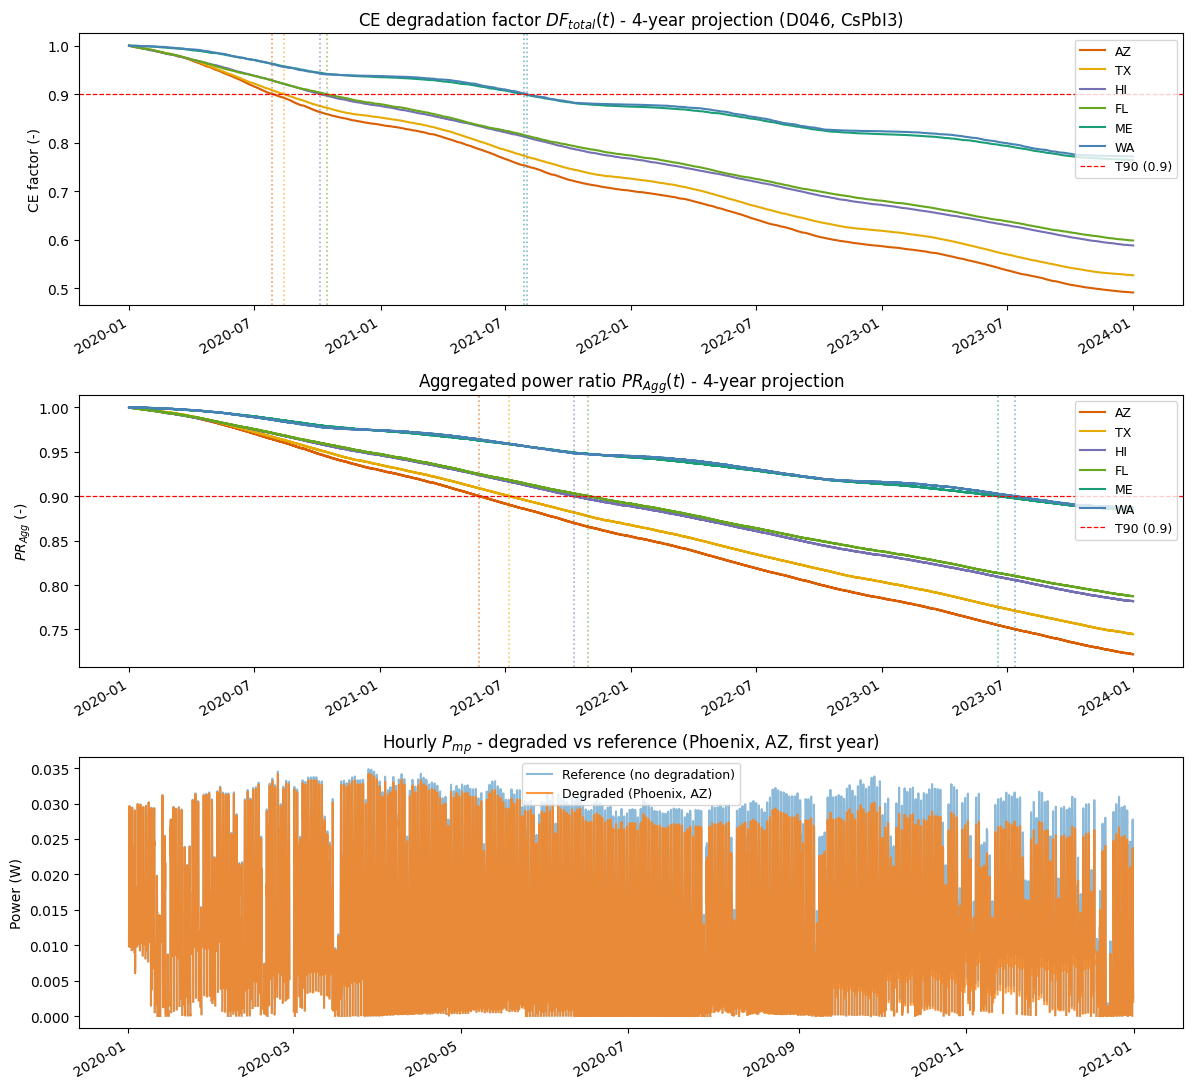

In [7]:

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

# Panel 1: CE degradation factor DF_total(t) - all locations + T90 crossings
for loc, ce in ce_multiyear.items():
    ce.plot(ax=axes[0], label=loc, color=_colors[loc])
    t_idx = ce[ce <= T_THRESHOLD].index
    if len(t_idx):
        axes[0].axvline(t_idx[0], color=_colors[loc], ls=":", alpha=0.6, lw=1.2)
axes[0].axhline(
    T_THRESHOLD, color="red", ls="--", lw=0.9, label=f"{T_LABEL} ({T_THRESHOLD})"
)
axes[0].set_ylabel("CE factor (-)")
axes[0].set_title(
    f"CE degradation factor $DF_{{total}}(t)$ - {N_YEARS}-year projection (D046, CsPbI3)"
)
axes[0].legend(fontsize=9, loc="upper right")

# Panel 2: Aggregated power ratio PR_Agg(t) - all locations + T90,Agg crossings
for loc, pr in pr_multiyear.items():
    pr.plot(ax=axes[1], label=loc, color=_colors[loc])
    t_idx = pr[pr <= T_THRESHOLD].index
    if len(t_idx):
        axes[1].axvline(t_idx[0], color=_colors[loc], ls=":", alpha=0.6, lw=1.2)
axes[1].axhline(
    T_THRESHOLD, color="red", ls="--", lw=0.9, label=f"{T_LABEL} ({T_THRESHOLD})"
)
axes[1].set_ylabel("$PR_{Agg}$ (-)")
axes[1].set_title(f"Aggregated power ratio $PR_{{Agg}}(t)$ - {N_YEARS}-year projection")
axes[1].legend(fontsize=9, loc="upper right")

# Panel 3: Hourly power - degraded vs reference (first year, representative
# location chosen from LOCATIONS_TO_RUN order, using the first location that
# is available in ey_local).
_rep_loc = next(loc for loc in LOCATIONS_TO_RUN if loc in ey_local)
_rep_label = STATES[_rep_loc][2]
_wa = ey_local[_rep_loc]
_p_ref, _p_deg = _wa["power_reference"], _wa["power_degraded"]
_first_year = _p_ref.index < _p_ref.index[0] + pd.DateOffset(years=1)
_p_ref[_first_year].plot(ax=axes[2], label="Reference (no degradation)", alpha=0.5)
_p_deg[_first_year].plot(ax=axes[2], label=f"Degraded ({_rep_label})", alpha=0.8)
axes[2].set_ylabel("Power (W)")
axes[2].set_title(
    f"Hourly $P_{{mp}}$ - degraded vs reference ({_rep_label}, first year)"
)
axes[2].legend(fontsize=9)

fig.tight_layout()

## 5. Comparison with the original publication

Comparison between reference publication and this workflow.

Notes:
- Weather: pvdeg uses NSRDB PSM4 tmy and PVGIS TMY; Orooji used NREL/NLR TMY3.
- Device: this notebook now uses a PVCircuit Multi2T Perovskite/Si tandem. CE degradation from D046 is    applied to the top subcell only, consistent with the top-cell degradation framing.
- Array orientation: fixed-tilt, equator-facing, tilt = site latitude (a standard annual-optimal
  assumption). Tilt is not specified in the Orooji methodology.
- Reference Jsc: `reference_jsc_from_spectrum()` uses measured perovskite/Si EQE curves
  (`tutorials/data/orooji_liu_eqe.csv`, digitized from the Liu et al. 2024 Nature 635, 596-603
  reference device that Orooji parameterizes against)

In [36]:

# Orooji published reference values
OROOJI_T90 = {
    "AZ": 26,
    "TX": 29,
    "HI": 32,
    "FL": 35,
    "ME": 40,
    "WA": 42,
}
OROOJI_FIG4 = {
    "AZ": (0.83, 0.95),
    "WA": (0.90, 0.97),
}
CLIMATE = {
    "AZ": "arid",
    "TX": "arid",
    "FL": "tropical",
    "HI": "tropical",
    "WA": "temperate",
    "ME": "temperate",
}
_ccolor = {"arid": "#d95f02", "temperate": "#1b9e77", "tropical": "#7570b3"}


def _at_one_year(series):
    """Value of a tiled multi-year series at the 12-month mark."""
    return float(series.asof(series.index[0] + pd.DateOffset(years=1)))


# Fig-4 sites: reuse the CE / PR_Agg series already computed in Section 4 for AZ / WA -
# skips any Fig-4 site not in LOCATIONS_TO_RUN so this still works with a subset.
psm4_ce = {st: ce_multiyear[st] for st in OROOJI_FIG4 if st in ce_multiyear}
psm4_pr = {st: pr_multiyear[st] for st in OROOJI_FIG4 if st in pr_multiyear}

CE & PR_Agg at 12 months  (PSM4 / Orooji Fig 4):
loc  CE_PSM4  CE_Orooji  PRagg_PSM4  PRagg_Orooji
 AZ    0.837       0.83       0.929          0.95
 WA    0.937       0.90       0.974          0.97


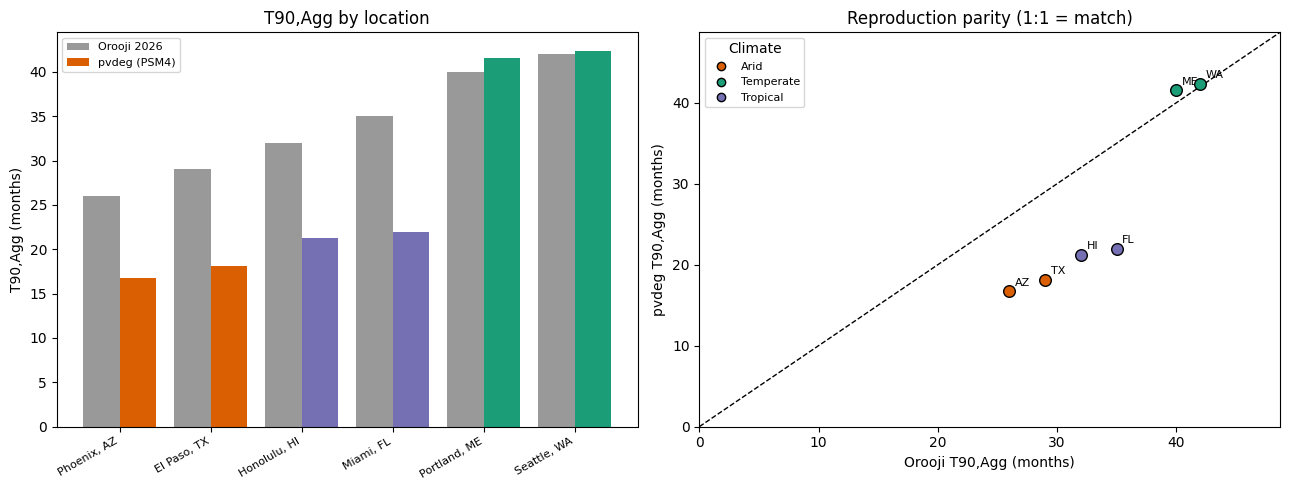

In [37]:
# Publication comparison: plots + 12-month table
# T90,Agg by location, built from the T90-crossing months already computed in Section 4.
# Uses LOCATIONS_TO_RUN so this works whether all 6 or just a subset were run.
cmp = pd.DataFrame(
    {
        "state": LOCATIONS_TO_RUN,
        "location": [STATES[loc][2] for loc in LOCATIONS_TO_RUN],
        "T_months": [t90_months[loc] for loc in LOCATIONS_TO_RUN],
    }
)
cmp["orooji_T90"] = cmp["state"].map(OROOJI_T90)
cmp["climate"] = cmp["state"].map(CLIMATE)
cmp = cmp.dropna(subset=["T_months", "orooji_T90"]).sort_values("orooji_T90")

if cmp.empty:
    print("No locations reached T90 within N_YEARS - run Section 4 first.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    xpos, w = np.arange(len(cmp)), 0.4
    ax1.bar(xpos - w / 2, cmp["orooji_T90"], w, label="Orooji 2026", color="0.6")
    ax1.bar(
        xpos + w / 2,
        cmp["T_months"],
        w,
        label="pvdeg (PSM4)",
        color=[_ccolor[c] for c in cmp["climate"]],
    )
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(cmp["location"], rotation=30, ha="right", fontsize=8)
    ax1.set_ylabel(f"{T_LABEL},Agg (months)")
    ax1.set_title(f"{T_LABEL},Agg by location")
    ax1.legend(fontsize=8)

    lim = max(cmp["orooji_T90"].max(), cmp["T_months"].max()) * 1.15
    ax2.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    for _, r in cmp.iterrows():
        ax2.scatter(
            r["orooji_T90"],
            r["T_months"],
            s=70,
            color=_ccolor[r["climate"]],
            edgecolor="k",
            zorder=3,
        )
        ax2.annotate(
            r["state"],
            (r["orooji_T90"], r["T_months"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax2.set_xlim(0, lim)
    ax2.set_ylim(0, lim)
    ax2.set_xlabel(f"Orooji {T_LABEL},Agg (months)")
    ax2.set_ylabel(f"pvdeg {T_LABEL},Agg (months)")
    ax2.set_title("Reproduction parity (1:1 = match)")
    ax2.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                ls="",
                color=c,
                label=k.title(),
                markeredgecolor="k",
            )
            for k, c in _ccolor.items()
        ],
        fontsize=8,
        title="Climate",
    )
    fig.tight_layout()

    # CE & PR_Agg at 12 months - only the Fig-4 sites (AZ, WA) that were actually run.
    rows = []
    for st in OROOJI_FIG4:
        if st not in psm4_ce:
            continue
        rows.append(
            {
                "loc": st,
                "CE_PSM4": round(_at_one_year(psm4_ce[st]), 3),
                "CE_Orooji": OROOJI_FIG4[st][0],
                "PRagg_PSM4": round(_at_one_year(psm4_pr[st]), 3),
                "PRagg_Orooji": OROOJI_FIG4[st][1],
            }
        )
    if rows:
        print("CE & PR_Agg at 12 months  (PSM4 / Orooji Fig 4):")
        print(pd.DataFrame(rows).to_string(index=False))
    else:
        print("No Fig-4 sites (AZ, WA) in LOCATIONS_TO_RUN - skipping 12-month table.")

In [ ]:
# Meteorological comparison
I_REF = d046.get("Iref", 1200.0)

diag_rows = []
for loc in LOCATIONS_TO_RUN:
    wdf = all_weather[loc]
    mt = all_meta[loc]
    ghi_annual_kwh = wdf["ghi"].sum() / 1000.0  # kWh/m2/yr (single TMY year)
    dni_annual_kwh = wdf["dni"].sum() / 1000.0
    t_air_mean = wdf["temp_air"].mean()
    t_air_max = wdf["temp_air"].max()
    wind_mean = wdf["wind_speed"].mean() if "wind_speed" in wdf else float("nan")

    # Make this diagnostic independent of earlier execution order.
    lat_here = float(mt.get("latitude", STATES[loc][0]))
    tilt_here = float(mt.get("tilt", abs(lat_here)))
    az_here = float(mt.get("azimuth", 180.0))

    # Recompute POA + NOCT cell temp for this single TMY year (fixed-tilt,
    # tilt=latitude) exactly as ey_pipeline() does, to get the realized stress.
    poa = pvdeg.spectral.poa_irradiance(wdf, mt, tilt=tilt_here, azimuth=az_here)
    t_cell = orooji_noct_cell_temp(wdf, poa)
    mean_I_over_Iref = (poa["poa_global"] / I_REF).mean()
    frac_hours_stressed = (poa["poa_global"] > 0).mean()

    diag_rows.append(
        {
            "loc": loc,
            "climate": CLIMATE.get(loc),
            "GHI (kWh/m2/yr)": round(ghi_annual_kwh, 0),
            "DNI (kWh/m2/yr)": round(dni_annual_kwh, 0),
            "T_air mean (C)": round(t_air_mean, 1),
            "T_air max (C)": round(t_air_max, 1),
            "wind mean (m/s)": round(wind_mean, 2),
            "T_cell mean, daylight (C)": round(
                t_cell[t_cell.index[poa["poa_global"].values > 0]].mean(), 1
            ),
            "mean I/Iref (all hrs)": round(mean_I_over_Iref, 3),
            f"{T_LABEL},Agg pvdeg (mo)": (
                round(t90_months[loc], 1) if t90_months.get(loc) else None
            ),
            f"{T_LABEL},Agg Orooji (mo)": OROOJI_T90.get(loc),
        }
    )

diag_df = pd.DataFrame(diag_rows).sort_values("T_air mean (C)")
print("Per-location weather/stress diagnostic (single TMY year, fixed-tilt):")
print(diag_df.to_string(index=False))

Per-location weather/stress diagnostic (single TMY year, fixed-tilt):
loc   climate  GHI (kWh/m2/yr)  DNI (kWh/m2/yr)  T_air mean (C)  T_air max (C)  wind mean (m/s)  T_cell mean, daylight (C)  mean I/Iref (all hrs)  T90,Agg pvdeg (mo)  T90,Agg Orooji (mo)
 ME temperate           1428.0           1547.0             8.2           27.1             2.57                       23.5                  0.152                41.5                   40
 WA temperate           1276.0           1305.0            11.1           34.6             0.70                       25.1                  0.132                42.3                   42
 TX      arid           2184.0           2784.0            17.9           40.2             2.72                       41.5                  0.229                18.2                   29
 AZ      arid           2127.0           2670.0            23.1           46.2             1.98                       46.7                  0.224                16.7                 

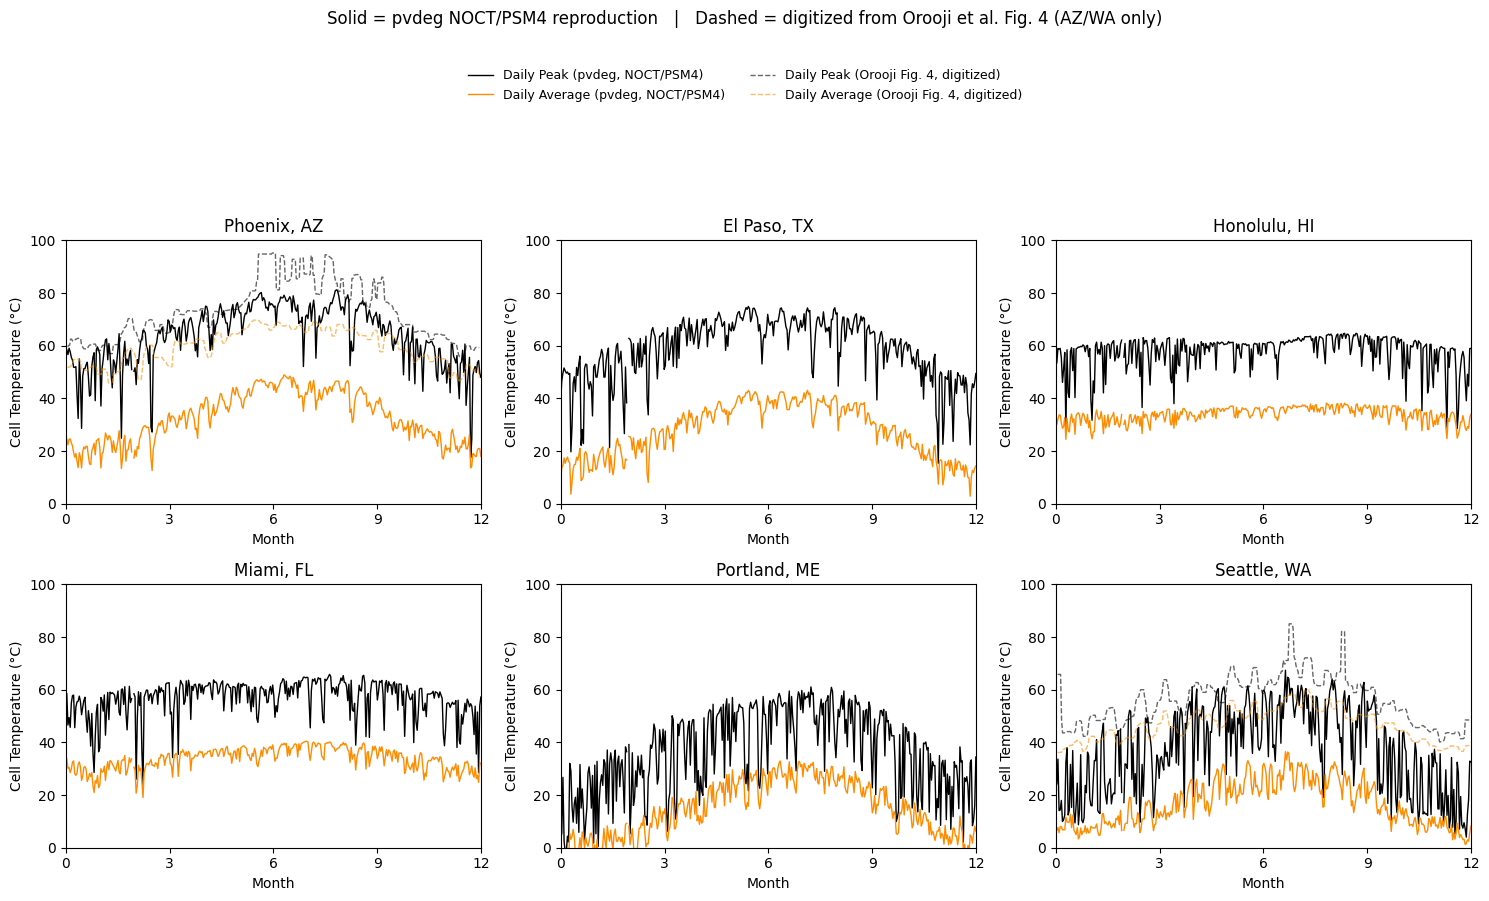

In [51]:
## --- Overlay: pvdeg NOCT/PSM4 T_cell vs. digitized Orooji Fig. 4 (all locations; paper data only for AZ/WA) ---
# Orooji Fig. 4 only publishes Daily Peak / Daily Average cell-temperature curves for
# two representative locations (Phoenix AZ = hot/arid, Seattle WA = mild/cloudy), so
# the digitized paper overlay (dashed) is only available for those two - digitized
# directly from the published figure (page 9/14) via pixel-color tracking (black ->
# Daily Peak, orange -> Daily Average), calibrated against the axes (0-12 months,
# 0-100 degC). See tutorials/data/orooji_fig4_celltemp_digitized.csv.
# The other four locations show pvdeg's own reproduction (solid) only, with no
# paper ground-truth available, but are included for a complete cross-climate picture.
digitized_path = os.path.join(TUTORIALS_DATA, "orooji_fig4_celltemp_digitized.csv")
fig4_digitized = pd.read_csv(digitized_path)
_fig4_locs = set(fig4_digitized["location"].unique())

_n = len(LOCATIONS_TO_RUN)
_ncols = 3
_nrows = -(-_n // _ncols)  # ceil
fig, axes = plt.subplots(
    _nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False
)
axes_flat = axes.flatten()
for ax, loc in zip(axes_flat, LOCATIONS_TO_RUN):
    # pvdeg reproduction: full 24h daily peak/average of T_cell (NOCT model, PSM4 weather)
    t_cell = tcell_by_loc[loc]
    daily_peak = t_cell.resample("D").max()
    daily_mean = t_cell.resample("D").mean()
    month_pvdeg = (daily_peak.index - daily_peak.index[0]).days / 30.44

    ax.plot(
        month_pvdeg,
        daily_peak.values,
        color="black",
        lw=1.0,
        label="Daily Peak (pvdeg, NOCT/PSM4)",
    )
    ax.plot(
        month_pvdeg,
        daily_mean.values,
        color="darkorange",
        lw=1.0,
        label="Daily Average (pvdeg, NOCT/PSM4)",
    )

    if loc in _fig4_locs:
        d = fig4_digitized[fig4_digitized["location"] == loc]
        ax.plot(
            d["month"],
            d["daily_peak_C"],
            color="black",
            lw=1.0,
            ls="--",
            alpha=0.6,
            label="Daily Peak (Orooji Fig. 4, digitized)",
        )
        ax.plot(
            d["month"],
            d["daily_avg_C"],
            color="darkorange",
            lw=1.0,
            ls="--",
            alpha=0.6,
            label="Daily Average (Orooji Fig. 4, digitized)",
        )

    ax.set_ylim(0, 100)
    ax.set_xlim(0, 12)
    ax.set_xticks([0, 3, 6, 9, 12])
    ax.set_xlabel("Month")
    ax.set_ylabel("Cell Temperature (°C)")
    ax.set_title(f"{STATES[loc][2]}")

for ax in axes_flat[_n:]:
    ax.set_visible(False)

_legend_handles = [
    Line2D([0], [0], color="black", lw=1.0, label="Daily Peak (pvdeg, NOCT/PSM4)"),
    Line2D(
        [0], [0], color="darkorange", lw=1.0, label="Daily Average (pvdeg, NOCT/PSM4)"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=1.0,
        ls="--",
        alpha=0.6,
        label="Daily Peak (Orooji Fig. 4, digitized)",
    ),
    Line2D(
        [0],
        [0],
        color="darkorange",
        lw=1.0,
        ls="--",
        alpha=0.6,
        label="Daily Average (Orooji Fig. 4, digitized)",
    ),
]
fig.legend(
    handles=_legend_handles,
    loc="upper center",
    ncol=2,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.suptitle(
    "Solid = pvdeg NOCT/PSM4 reproduction   |   Dashed = digitized from Orooji et al. Fig. 4 (AZ/WA only)",
    y=1.12,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

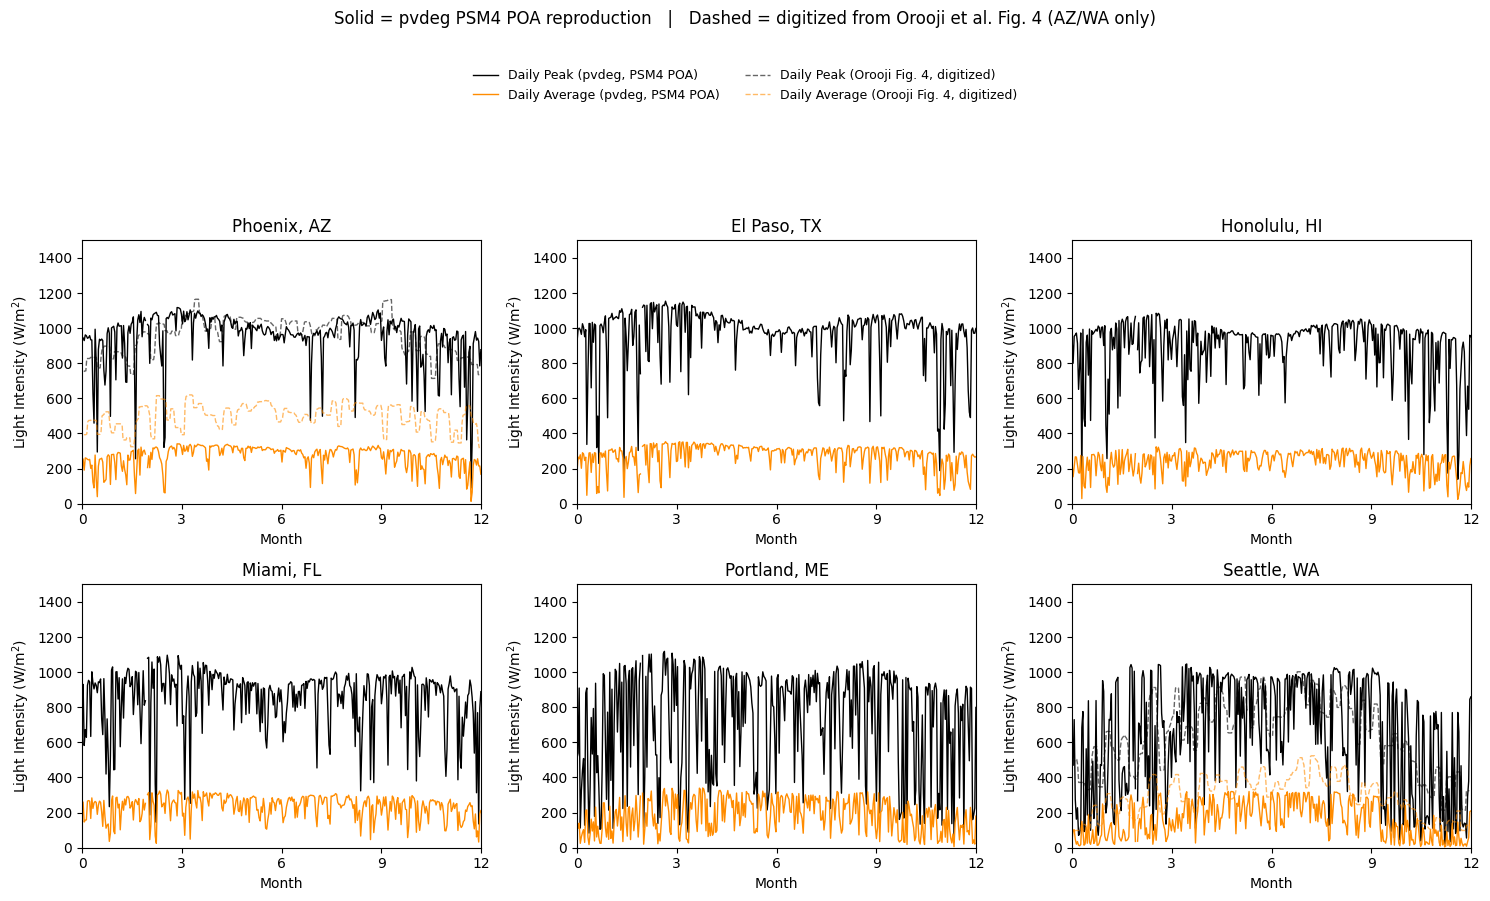

In [52]:
## --- Overlay: pvdeg PSM4 POA irradiance vs. digitized Orooji Fig. 4 "Light Intensity" (all locations; paper data only for AZ/WA) ---
# Orooji Fig. 4 only publishes Daily Peak / Daily Average "Light Intensity" curves
# (the panel directly below the cell-temperature panel, y-axis 0-1500 W/m^2) for the
# same two representative locations (AZ, WA), digitized the same way as the
# temperature curves: pixel-color tracking (black -> Daily Peak, orange -> Daily
# Average), calibrated against the axes (0-12 months, 0-1500 W/m^2). See
# tutorials/data/orooji_fig4_irradiance_digitized.csv.
# The other four locations show pvdeg's own POA reproduction (solid) only, with no
# paper ground-truth available, but are included for a complete cross-climate picture.
irr_digitized_path = os.path.join(
    TUTORIALS_DATA, "orooji_fig4_irradiance_digitized.csv"
)
fig4_irr_digitized = pd.read_csv(irr_digitized_path)
_fig4_irr_locs = set(fig4_irr_digitized["location"].unique())

_n = len(LOCATIONS_TO_RUN)
_ncols = 3
_nrows = -(-_n // _ncols)  # ceil
fig, axes = plt.subplots(
    _nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False
)
axes_flat = axes.flatten()
for ax, loc in zip(axes_flat, LOCATIONS_TO_RUN):
    # pvdeg reproduction: daily peak/average of POA global irradiance (PSM4 weather)
    poa_global = poa_by_loc[loc]["poa_global"]
    daily_peak_poa = poa_global.resample("D").max()
    daily_mean_poa = poa_global.resample("D").mean()
    month_pvdeg = (daily_peak_poa.index - daily_peak_poa.index[0]).days / 30.44

    ax.plot(
        month_pvdeg,
        daily_peak_poa.values,
        color="black",
        lw=1.0,
        label="Daily Peak (pvdeg, PSM4 POA)",
    )
    ax.plot(
        month_pvdeg,
        daily_mean_poa.values,
        color="darkorange",
        lw=1.0,
        label="Daily Average (pvdeg, PSM4 POA)",
    )

    if loc in _fig4_irr_locs:
        d = fig4_irr_digitized[fig4_irr_digitized["location"] == loc]
        ax.plot(
            d["month"],
            d["daily_peak_Wm2"],
            color="black",
            lw=1.0,
            ls="--",
            alpha=0.6,
            label="Daily Peak (Orooji Fig. 4, digitized)",
        )
        ax.plot(
            d["month"],
            d["daily_avg_Wm2"],
            color="darkorange",
            lw=1.0,
            ls="--",
            alpha=0.6,
            label="Daily Average (Orooji Fig. 4, digitized)",
        )

    ax.set_ylim(0, 1500)
    ax.set_xlim(0, 12)
    ax.set_xticks([0, 3, 6, 9, 12])
    ax.set_xlabel("Month")
    ax.set_ylabel("Light Intensity (W/m$^2$)")
    ax.set_title(f"{STATES[loc][2]}")

for ax in axes_flat[_n:]:
    ax.set_visible(False)

_legend_handles = [
    Line2D([0], [0], color="black", lw=1.0, label="Daily Peak (pvdeg, PSM4 POA)"),
    Line2D(
        [0], [0], color="darkorange", lw=1.0, label="Daily Average (pvdeg, PSM4 POA)"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=1.0,
        ls="--",
        alpha=0.6,
        label="Daily Peak (Orooji Fig. 4, digitized)",
    ),
    Line2D(
        [0],
        [0],
        color="darkorange",
        lw=1.0,
        ls="--",
        alpha=0.6,
        label="Daily Average (Orooji Fig. 4, digitized)",
    ),
]
fig.legend(
    handles=_legend_handles,
    loc="upper center",
    ncol=2,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.suptitle(
    "Solid = pvdeg PSM4 POA reproduction   |   Dashed = digitized from Orooji et al. Fig. 4 (AZ/WA only)",
    y=1.12,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

In [53]:
# Quantitative pvdeg-vs-digitized-Orooji-Fig.4 gap check (AZ, WA), for both
# T_cell and POA "Light Intensity" panels -- annual mean of the daily-peak curve
# and annual mean of the daily-average curve, each compared directly (not just
# eyeballed off the plots above).
_rows = []
for loc in ["AZ", "WA"]:
    t_cell = tcell_by_loc[loc]
    poa_global = poa_by_loc[loc]["poa_global"]
    d_tc = fig4_digitized[fig4_digitized["location"] == loc]
    d_irr = fig4_irr_digitized[fig4_irr_digitized["location"] == loc]

    _rows.append(
        {
            "location": loc,
            "Tcell peak: pvdeg": t_cell.resample("D").max().mean(),
            "Tcell peak: Orooji": d_tc["daily_peak_C"].mean(),
            "Tcell avg: pvdeg": t_cell.resample("D").mean().mean(),
            "Tcell avg: Orooji": d_tc["daily_avg_C"].mean(),
            "POA peak: pvdeg": poa_global.resample("D").max().mean(),
            "POA peak: Orooji": d_irr["daily_peak_Wm2"].mean(),
            "POA avg: pvdeg": poa_global.resample("D").mean().mean(),
            "POA avg: Orooji": d_irr["daily_avg_Wm2"].mean(),
        }
    )

gap_df = pd.DataFrame(_rows).set_index("location")
pd.set_option("display.width", 160)
print(gap_df.T.round(1))

location               AZ     WA
Tcell peak: pvdeg    63.6   37.4
Tcell peak: Orooji   72.9   56.2
Tcell avg: pvdeg     32.5   16.7
Tcell avg: Orooji    59.6   46.6
POA peak: pvdeg     951.9  649.2
POA peak: Orooji    963.2  651.6
POA avg: pvdeg      269.1  158.4
POA avg: Orooji     499.6  292.2


## 7. Conclusions and next step

Conclusions from this notebook and controlled tests:
- D046 activation energies used here are consistent with the uncapped-device interpretation.
- WA is reproduced well for $T_{90,Agg}$.
- AZ remains substantially faster than published in long-horizon $PR_{Agg}$ decline.
- The mismatch is not explained by hotter/brighter weather in this workflow.
- The tandem mismatch hypothesis was tested directly and did not close the AZ gap.

Most useful next step:
- Compare the full AZ $CE(t)$ trajectory shape against Orooji's digitized curve (not only the 12-month point), then re-check how that trajectory propagates into $PR_{Agg}(t)$.